# 1.Thư viện và Cấu hình đường dẫn

In [1]:
from pathlib import Path
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = Path.cwd().parent
TFIDF_PATH = PROJECT_ROOT / "data" / "processed" / "tfidf_features.pkl"

# 2.Load dữ liệu và Phân chia Train/Test

In [2]:
data = joblib.load(TFIDF_PATH)
X = data["matrix"]
labels = data["labels"]

label_map = {"negative": 0, "positive": 1}
y = np.array([label_map[lbl] for lbl in labels])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập kiểm thử   X_test : {X_test.shape}")

Kích thước tập huấn luyện X_train: (8757, 7308)
Kích thước tập kiểm thử   X_test : (2190, 7308)


# 3.Chạy thực nghiệm Logistic Regression & Naive Bayes & SVM

In [3]:
# 1. Nạp trực tiếp mô hình từ thư mục models/baseline đã được huấn luyện trước đó
lr_model = joblib.load(PROJECT_ROOT / "models" / "baseline" / "logistic_regression_baseline.joblib")
nb_model = joblib.load(PROJECT_ROOT / "models" / "baseline" / "naive_bayes_baseline.joblib")
svm_model = joblib.load(PROJECT_ROOT / "models" / "baseline" / "svm_baseline.joblib")

# 2. Dự đoán đầu ra trên tập Test và lưu kết quả vào biến y_pred_lr, y_pred_nb, y_pred_svm tương ứng với từng mô hình
y_pred_lr = lr_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

# 3. In báo cáo kết quả cho từng mô hình
print("--- LOGISTIC REGRESSION ---")
print(classification_report(y_test, y_pred_lr, target_names=["negative", "positive"]))

print("\n--- MULTINOMIAL NAIVE BAYES ---")
print(classification_report(y_test, y_pred_nb, target_names=["negative", "positive"]))

print("\n--- SUPPORT VECTOR MACHINE (LinearSVC) ---")
print(classification_report(y_test, y_pred_svm, target_names=["negative", "positive"]))

--- LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

    negative       0.95      0.92      0.93      1329
    positive       0.88      0.92      0.90       861

    accuracy                           0.92      2190
   macro avg       0.91      0.92      0.92      2190
weighted avg       0.92      0.92      0.92      2190


--- MULTINOMIAL NAIVE BAYES ---
              precision    recall  f1-score   support

    negative       0.96      0.87      0.91      1329
    positive       0.82      0.94      0.88       861

    accuracy                           0.90      2190
   macro avg       0.89      0.90      0.89      2190
weighted avg       0.90      0.90      0.90      2190


--- SUPPORT VECTOR MACHINE (LinearSVC) ---
              precision    recall  f1-score   support

    negative       0.96      0.92      0.94      1329
    positive       0.88      0.94      0.91       861

    accuracy                           0.93      2190
   macro avg       0.92

# 4.Phân tích sâu trọng số của mô hình SVM (Model Interpretability)

In [4]:
feature_names = np.array(data["vectorizer"].get_feature_names_out())
coefficients = svm_model.coef_[0]

top_positive_idx = np.argsort(coefficients)[-10:]
top_negative_idx = np.argsort(coefficients)[:10]

print("=== TOP 10 TỪ/N-GRAM MANG TÍNH TÍCH CỰC (POSITIVE) ===")
for idx in reversed(top_positive_idx):
    print(f"Từ/Cụm từ: '{feature_names[idx]}' | Trọng số tác động = {coefficients[idx]:.4f}")

print("\n=== TOP 10 TỪ/N-GRAM MANG TÍNH TIÊU CỰC (NEGATIVE) ===")
for idx in top_negative_idx:
    print(f"Từ/Cụm từ: '{feature_names[idx]}' | Trọng số tác động = {coefficients[idx]:.4f}")

=== TOP 10 TỪ/N-GRAM MANG TÍNH TÍCH CỰC (POSITIVE) ===
Từ/Cụm từ: 'không móp' | Trọng số tác động = 2.6864
Từ/Cụm từ: 'không bết' | Trọng số tác động = 2.1956
Từ/Cụm từ: 'đẹp' | Trọng số tác động = 2.1477
Từ/Cụm từ: 'chưa không' | Trọng số tác động = 2.0107
Từ/Cụm từ: 'giao hàng' | Trọng số tác động = 1.9004
Từ/Cụm từ: 'không sợ' | Trọng số tác động = 1.8612
Từ/Cụm từ: 'ổn' | Trọng số tác động = 1.8553
Từ/Cụm từ: 'ưng' | Trọng số tác động = 1.7731
Từ/Cụm từ: 'hời' | Trọng số tác động = 1.7698
Từ/Cụm từ: 'ngon' | Trọng số tác động = 1.7163

=== TOP 10 TỪ/N-GRAM MANG TÍNH TIÊU CỰC (NEGATIVE) ===
Từ/Cụm từ: 'không' | Trọng số tác động = -3.3507
Từ/Cụm từ: 'tệ' | Trọng số tác động = -3.0448
Từ/Cụm từ: 'thất_vọng' | Trọng số tác động = -2.3404
Từ/Cụm từ: 'kém' | Trọng số tác động = -2.1619
Từ/Cụm từ: 'không thơm' | Trọng số tác động = -2.0693
Từ/Cụm từ: 'hắc' | Trọng số tác động = -1.9289
Từ/Cụm từ: 'móp' | Trọng số tác động = -1.8722
Từ/Cụm từ: 'chẳng' | Trọng số tác động = -1.8225
Từ/Cụm 

# 5.Trực quan hóa Confusion Matrix của cả 3 Baseline Models

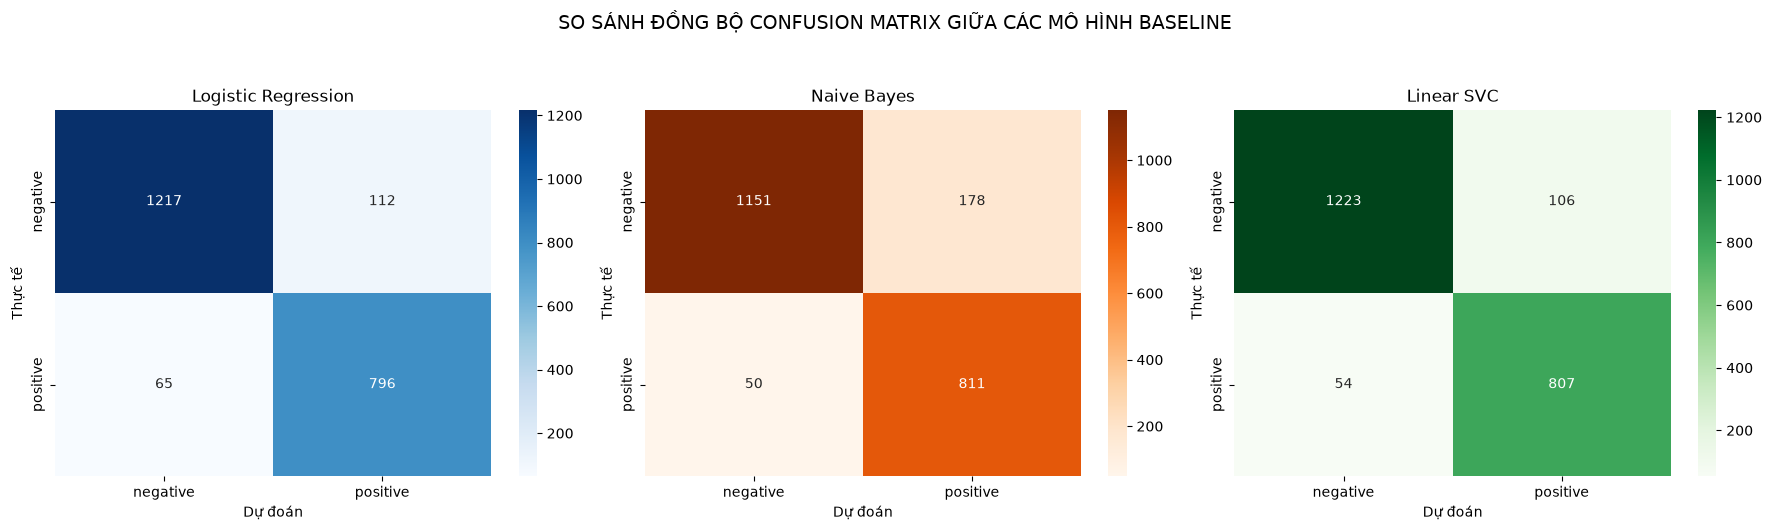

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Logistic Regression Heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
axes[0].set_title("Logistic Regression")
axes[0].set_ylabel("Thực tế")
axes[0].set_xlabel("Dự đoán")

# 2. Naive Bayes Heatmap
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
axes[1].set_title("Naive Bayes")
axes[1].set_ylabel("Thực tế")
axes[1].set_xlabel("Dự đoán")

# 3. SVM Heatmap
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
axes[2].set_title("Linear SVC")
axes[2].set_ylabel("Thực tế")
axes[2].set_xlabel("Dự đoán")

plt.suptitle("SO SÁNH ĐỒNG BỘ CONFUSION MATRIX GIỮA CÁC MÔ HÌNH BASELINE", fontsize=14, y=1.05)
plt.tight_layout()

# --- ĐOẠN CODE THÊM VÀO ĐỂ LƯU ẢNH ---
figures_dir = PROJECT_ROOT / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)  # Tự động tạo thư mục nếu chưa có
plt.savefig(figures_dir / "baseline_confusion_matrices.png", bbox_inches='tight', dpi=300)
# -------------------------------------

plt.suptitle("SO SÁNH ĐỒNG BỘ CONFUSION MATRIX GIỮA CÁC MÔ HÌNH BASELINE", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# 6.Xuất số liệu ra reports/tables/

In [6]:
import pandas as pd

# 1. Lấy báo cáo dưới dạng dictionary cấu trúc dữ liệu
report_lr = classification_report(y_test, y_pred_lr, target_names=["negative", "positive"], output_dict=True)
report_nb = classification_report(y_test, y_pred_nb, target_names=["negative", "positive"], output_dict=True)
report_svm = classification_report(y_test, y_pred_svm, target_names=["negative", "positive"], output_dict=True)

# 2. Gom các chỉ số quan trọng (Accuracy và F1-Score của các lớp) thành cấu trúc bảng
baseline_summary = {
    "Model": ["Logistic Regression", "Multinomial Naive Bayes", "Linear SVM"],
    "Accuracy": [report_lr["accuracy"], report_nb["accuracy"], report_svm["accuracy"]],
    "Negative_F1": [report_lr["negative"]["f1-score"], report_nb["negative"]["f1-score"], report_svm["negative"]["f1-score"]],
    "Positive_F1": [report_lr["positive"]["f1-score"], report_nb["positive"]["f1-score"], report_svm["positive"]["f1-score"]],
    "Macro_Avg_F1": [report_lr["macro avg"]["f1-score"], report_nb["macro avg"]["f1-score"], report_svm["macro avg"]["f1-score"]]
}

# 3. Tạo DataFrame và xuất file
df_compare = pd.DataFrame(baseline_summary)

tables_dir = PROJECT_ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)  # Tự động tạo thư mục nếu chưa có

# Lưu file csv bàn giao cho Phase 6
df_compare.to_csv(tables_dir / "baseline_model_comparison.csv", index=False)

print("=== ĐÃ XUẤT ĐẦY ĐỦ ARTIFACTS CHO PHASE 6 ===")
print(f"- Đã lưu ảnh đồ thị tại: reports/figures/baseline_confusion_matrices.png")
print(f"- Đã lưu bảng số liệu tại: reports/tables/baseline_model_comparison.csv")
display(df_compare)

=== ĐÃ XUẤT ĐẦY ĐỦ ARTIFACTS CHO PHASE 6 ===
- Đã lưu ảnh đồ thị tại: reports/figures/baseline_confusion_matrices.png
- Đã lưu bảng số liệu tại: reports/tables/baseline_model_comparison.csv


,Model,Accuracy,Negative_F1,Positive_F1,Macro_Avg_F1
0,Logistic Regression,0.919178,0.932210,0.899943,0.916077
1,Multinomial Naive Bayes,0.895890,0.909881,0.876757,0.893319
2,Linear SVM,0.926941,0.938603,0.909808,0.924206


# 7. Thời gian huấn luyện (Training Time)

Đo thời gian train của từng model để đánh giá thêm một chiều nữa ngoài độ chính xác: **tốc độ**. Một model chính xác nhưng train quá lâu có thể không thực tế khi dữ liệu lớn hơn. Với baseline ML (Logistic Regression, Naive Bayes, SVM), thời gian train thường rất nhanh — đây cũng là ưu điểm lớn so với Deep Learning (LSTM, PhoBERT).

Đang đo thời gian train...
Logistic Regression : 0.0186 giây
Naive Bayes         : 0.0020 giây
SVM (LinearSVC)     : 0.0250 giây

Đã lưu biểu đồ tại: reports/figures/baseline_training_time.png


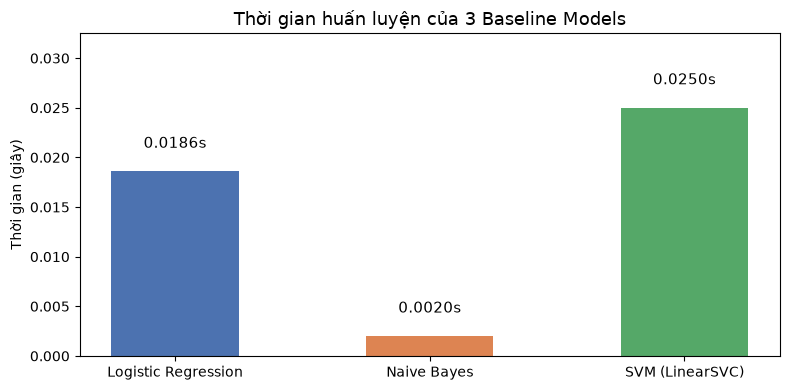

In [7]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Hàm đo thời gian train của 1 model
# time.time() trả về số giây tính từ epoch (01/01/1970) -> lấy hiệu
# trước/sau .fit() là ra thời gian train thực tế (đơn vị: giây).
def measure_train_time(model, X_train, y_train):
    start = time.time()       # ghi lại thời điểm BẮT ĐẦU train
    model.fit(X_train, y_train)
    end = time.time()         # ghi lại thời điểm KẾT THÚC train
    return model, round(end - start, 4)  # trả về model + số giây

# Train lại từng model và đo thời gian
# (Cần train lại vì chúng ta không lưu thời gian train lúc chạy train_*.py)
print("Đang đo thời gian train...")

_, time_lr = measure_train_time(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    X_train, y_train
)

_, time_nb = measure_train_time(
    MultinomialNB(class_prior=[0.5, 0.5]),
    X_train, y_train
)

_, time_svm = measure_train_time(
    LinearSVC(class_weight="balanced", random_state=42, max_iter=5000),
    X_train, y_train
)

print(f"Logistic Regression : {time_lr:.4f} giây")
print(f"Naive Bayes         : {time_nb:.4f} giây")
print(f"SVM (LinearSVC)     : {time_svm:.4f} giây")

# Vẽ biểu đồ cột so sánh thời gian train
fig, ax = plt.subplots(figsize=(8, 4))
models = ["Logistic Regression", "Naive Bayes", "SVM (LinearSVC)"]
times = [time_lr, time_nb, time_svm]
colors = ["#4C72B0", "#DD8452", "#55A868"]

bars = ax.bar(models, times, color=colors, width=0.5)

# Hiện số giây ngay trên đầu mỗi cột
for bar, t in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # vị trí x = giữa cột
        bar.get_height() + 0.002,            # vị trí y = ngay trên đỉnh cột
        f"{t:.4f}s",
        ha="center", va="bottom", fontsize=11
    )

ax.set_title("Thời gian huấn luyện của 3 Baseline Models", fontsize=13)
ax.set_ylabel("Thời gian (giây)")
ax.set_ylim(0, max(times) * 1.3)  # thêm khoảng trống phía trên cho label
plt.tight_layout()

# Lưu ảnh vào reports/figures/ để dùng trong báo cáo cuối
figures_dir = PROJECT_ROOT / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "baseline_training_time.png", dpi=150, bbox_inches="tight")
print(f"\nĐã lưu biểu đồ tại: reports/figures/baseline_training_time.png")
plt.show()

# 8. ROC-AUC Curve

**ROC (Receiver Operating Characteristic)** là đường cong thể hiện sự đánh đổi giữa:
- **True Positive Rate (TPR / Recall):** tỉ lệ review positive thật sự được model bắt đúng
- **False Positive Rate (FPR):** tỉ lệ review negative bị đoán nhầm thành positive

**AUC (Area Under Curve):** diện tích dưới đường ROC, nằm trong khoảng [0, 1].
AUC = 1.0 là model hoàn hảo, AUC = 0.5 là model đoán ngẫu nhiên (không có giá trị).
AUC càng gần 1 thì model càng phân biệt tốt 2 lớp positive/negative.

**Lưu ý kỹ thuật:** `LinearSVC` không có hàm `predict_proba()` (không tính xác suất)
nên ta dùng `decision_function()` thay thế — trả về khoảng cách tới đường biên phân chia,
giá trị càng dương thì model càng "chắc" là positive, giá trị càng âm thì càng "chắc" là negative.

Đã lưu biểu đồ tại: reports/figures/baseline_roc_curve.png


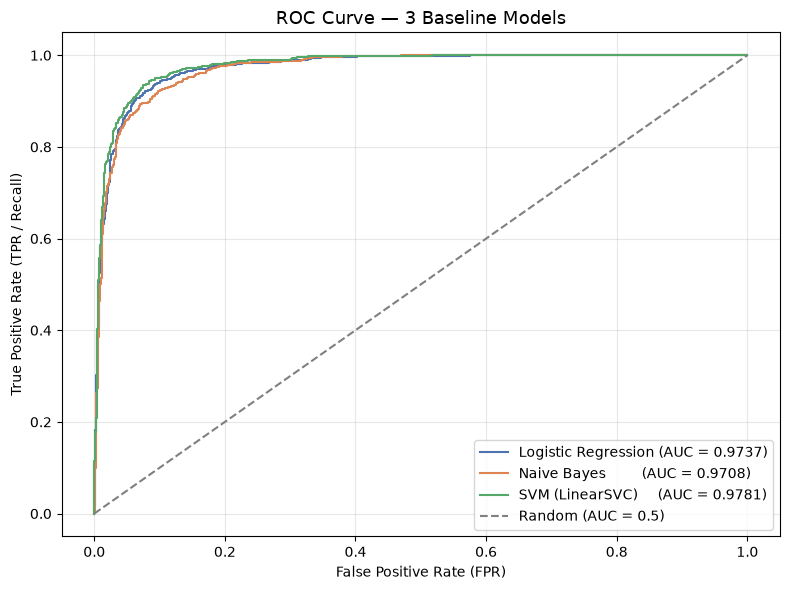


AUC Score:
  Logistic Regression : 0.9737
  Naive Bayes         : 0.9708
  SVM (LinearSVC)     : 0.9781


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score

# Lấy "điểm tin cậy" (score) của từng model cho lớp positive
# Logistic Regression và Naive Bayes có predict_proba() -> lấy cột [:, 1]
# (cột thứ 1 = xác suất thuộc lớp positive)
scores_lr = lr_model.predict_proba(X_test)[:, 1]
scores_nb = nb_model.predict_proba(X_test)[:, 1]

# LinearSVC không có predict_proba() -> dùng decision_function() thay thế
# (khoảng cách tới đường biên, giá trị dương = nghiêng về positive)
scores_svm = svm_model.decision_function(X_test)

# roc_curve trả về 3 mảng: fpr (False Positive Rate), tpr (True Positive Rate),
# và các ngưỡng (thresholds) tương ứng — để vẽ đường cong ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, scores_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, scores_nb)
fpr_svm, tpr_svm, _ = roc_curve(y_test, scores_svm)

# roc_auc_score tính AUC — 1 con số tóm tắt chất lượng của đường ROC
auc_lr = roc_auc_score(y_test, scores_lr)
auc_nb = roc_auc_score(y_test, scores_nb)
auc_svm = roc_auc_score(y_test, scores_svm)

# Vẽ 3 đường ROC trên cùng 1 biểu đồ để so sánh
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})", color="#4C72B0")
ax.plot(fpr_nb, tpr_nb, label=f"Naive Bayes         (AUC = {auc_nb:.4f})", color="#DD8452")
ax.plot(fpr_svm, tpr_svm, label=f"SVM (LinearSVC)     (AUC = {auc_svm:.4f})", color="#55A868")

# Đường chéo = model đoán ngẫu nhiên (AUC = 0.5), dùng làm baseline tham chiếu
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random (AUC = 0.5)")

ax.set_title("ROC Curve — 3 Baseline Models", fontsize=13)
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR / Recall)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(figures_dir / "baseline_roc_curve.png", dpi=150, bbox_inches="tight")
print(f"Đã lưu biểu đồ tại: reports/figures/baseline_roc_curve.png")
plt.show()

print(f"\nAUC Score:")
print(f"  Logistic Regression : {auc_lr:.4f}")
print(f"  Naive Bayes         : {auc_nb:.4f}")
print(f"  SVM (LinearSVC)     : {auc_svm:.4f}")

# 9. Precision-Recall Curve

**Precision-Recall Curve** thể hiện sự đánh đổi giữa Precision và Recall ở các ngưỡng quyết định khác nhau:
- Ngưỡng **cao** → model chỉ đoán positive khi rất chắc → Precision cao, Recall thấp (bỏ lọt nhiều)
- Ngưỡng **thấp** → model đoán positive dễ dãi hơn → Recall cao, Precision thấp (nhầm nhiều)

**Tại sao cần Precision-Recall Curve ngoài ROC-AUC?**
Với dữ liệu **mất cân bằng nhãn** (negative nhiều hơn positive), ROC-AUC có thể cho kết quả
"trông đẹp" dù model thật ra không tốt với lớp thiểu số. Precision-Recall Curve tập trung
vào chính lớp thiểu số (positive) nên phản ánh trung thực hơn chất lượng model trong trường hợp này.

**AP (Average Precision):** tóm tắt toàn bộ đường cong thành 1 số — tương tự AUC nhưng cho
Precision-Recall. AP càng gần 1 thì model càng tốt với lớp positive.

Đã lưu biểu đồ tại: reports/figures/baseline_precision_recall_curve.png


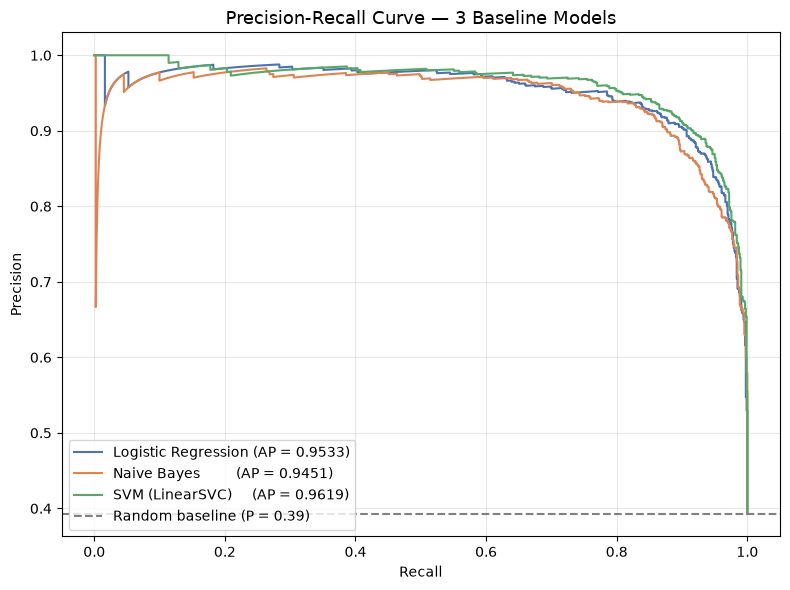


Average Precision (AP):
  Logistic Regression : 0.9533
  Naive Bayes         : 0.9451
  SVM (LinearSVC)     : 0.9619


In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Tính đường cong Precision-Recall cho từng model
# Dùng lại scores_lr, scores_nb, scores_svm đã tính ở cell ROC-AUC phía trên
# precision_recall_curve trả về 3 mảng: precision, recall, thresholds
prec_lr, rec_lr, _ = precision_recall_curve(y_test, scores_lr)
prec_nb, rec_nb, _ = precision_recall_curve(y_test, scores_nb)
prec_svm, rec_svm, _ = precision_recall_curve(y_test, scores_svm)

# Average Precision: tóm tắt đường cong thành 1 con số (tương tự AUC)
ap_lr = average_precision_score(y_test, scores_lr)
ap_nb = average_precision_score(y_test, scores_nb)
ap_svm = average_precision_score(y_test, scores_svm)

# Vẽ 3 đường Precision-Recall trên cùng 1 biểu đồ
fig, ax = plt.subplots(figsize=(8, 6))

# Lưu ý: trục x = Recall, trục y = Precision (khác với ROC là FPR vs TPR)
ax.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP = {ap_lr:.4f})", color="#4C72B0")
ax.plot(rec_nb, prec_nb, label=f"Naive Bayes         (AP = {ap_nb:.4f})", color="#DD8452")
ax.plot(rec_svm, prec_svm, label=f"SVM (LinearSVC)     (AP = {ap_svm:.4f})", color="#55A868")

# Đường ngang = tỉ lệ positive trong tập test (baseline đoán ngẫu nhiên)
# Nếu model chỉ đạt đến đường này thì không tốt hơn đoán random
baseline_ratio = y_test.sum() / len(y_test)
ax.axhline(y=baseline_ratio, linestyle="--", color="gray",
           label=f"Random baseline (P = {baseline_ratio:.2f})")

ax.set_title("Precision-Recall Curve — 3 Baseline Models", fontsize=13)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(figures_dir / "baseline_precision_recall_curve.png", dpi=150, bbox_inches="tight")
print(f"Đã lưu biểu đồ tại: reports/figures/baseline_precision_recall_curve.png")
plt.show()

print(f"\nAverage Precision (AP):")
print(f"  Logistic Regression : {ap_lr:.4f}")
print(f"  Naive Bayes         : {ap_nb:.4f}")
print(f"  SVM (LinearSVC)     : {ap_svm:.4f}")